In [ ]:
import sys
sys.path.append('models')
import os
import torch
import torch.optim as optim
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from model_3D_opt import MCAT_Surv
import torch.nn as nn

class MCATDataset(Dataset):
    def __init__(self, ct_dir, dsa_dir, samples_df):
        self.ct_dir = ct_dir
        self.dsa_dir = dsa_dir
        self.samples_df = samples_df
        self.samples = samples_df['Number'].tolist()
        self.labels = samples_df['label'].tolist()

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        
        sample_id = self.samples[idx]
        label = torch.tensor(self.labels[idx], dtype=torch.float32)

        ct_path = os.path.join(self.ct_dir, f"{sample_id}.pt")
        ct_feature = torch.load(ct_path,map_location='cpu') 

        dsa_path = os.path.join(self.dsa_dir, f"{sample_id}.pt")
        dsa_feature = torch.load(dsa_path,map_location='cpu')

        return ct_feature, dsa_feature, label, sample_id


def split_data_from_label_file(label_path, ct_feature_dir, dsa_feature_dir):
    df = pd.read_excel(label_path, dtype={'Number': str})
    
    # 获取 'set' 列中为 'val' 的样本作为验证集
    val_samples = df[df['set'] == 'val']
    
    # 获取 'set' 为 'fail' 和 'val' 的样本排除
    df_remaining = df[(df['set'] != 'val')&(df['set'] != 'fail')]
    
    # 按类别（0 和 1）各自抽取 40 个样本作为训练集
    train_0 = df_remaining[(df_remaining['label'] == 0)].sample(n=40, random_state=42)
    train_1 = df_remaining[(df_remaining['label'] == 1)].sample(n=40, random_state=42)

    # 合并训练集和验证集
    df_train = pd.concat([train_0, train_1]).reset_index(drop=True)
    df_val = val_samples.reset_index(drop=True)

    # 创建数据集
    train_dataset = MCATDataset(ct_feature_dir, dsa_feature_dir, df_train)
    val_dataset = MCATDataset(ct_feature_dir, dsa_feature_dir, df_val)

    return train_dataset, val_dataset


def train_model(model, dataloader, optimizer, criterion, device, log_file, all_train_results, epoch):
    model.train()
    total_loss, correct, total_samples = 0, 0, 0
    all_labels, all_probs, all_ids = [], [], []

    for ct_features, dsa_features, labels, sample_ids in dataloader:
        ct_features, dsa_features, labels = ct_features.to(device), dsa_features.to(device), labels.to(device)
        labels = labels.unsqueeze(1)

        optimizer.zero_grad()
        outputs, _ = model(ct_features, dsa_features)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = (outputs > 0.5).float()

        correct += (preds == labels).sum().item()
        total_samples += labels.numel()

        all_labels.extend(labels.cpu().numpy().flatten())
        all_probs.extend(preds.cpu().numpy().flatten())
        all_ids.extend(sample_ids)

    df = pd.DataFrame({"id": all_ids, "true": all_labels, f"pred_epoch_{epoch}": all_probs})
    all_train_results.append(df)

    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total_samples
    auc = roc_auc_score(all_labels, all_probs)

    log_file.write(f"Train - Loss: {avg_loss:.4f} | Acc: {accuracy:.4f} | AUC: {auc:.4f}\n")
    return avg_loss, accuracy, auc


def evaluate_model(model, dataloader, criterion, device, log_file, all_val_results, epoch):
    model.eval()
    total_loss, correct, total_samples = 0, 0, 0
    all_labels, all_probs, all_ids = [], [], []

    with torch.no_grad():
        for ct_features, dsa_features, labels, sample_ids in dataloader:
            ct_features, dsa_features, labels = ct_features.to(device), dsa_features.to(device), labels.to(device)
            labels = labels.unsqueeze(1)

            outputs, _ = model(ct_features, dsa_features)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            preds = (outputs > 0.5).float()
            correct += (preds == labels).sum().item()
            total_samples += labels.numel()

            all_labels.extend(labels.cpu().numpy().flatten())
            all_probs.extend(preds.cpu().numpy().flatten())
            all_ids.extend(sample_ids)

    df = pd.DataFrame({"id": all_ids, "true": all_labels, f"pred_epoch_{epoch}": all_probs})
    all_val_results.append(df)

    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total_samples
    auc = roc_auc_score(all_labels, all_probs)

    log_file.write(f"Val - Loss: {avg_loss:.4f} | Acc: {accuracy:.4f} | AUC: {auc:.4f}\n")
    return avg_loss, accuracy, auc


def main():
    ct_feature_dir = "./pretrain/data/features/features_ct"
    dsa_feature_dir = "./pretrain/data/features/features_dsa_resnet"
    label_path = "./label.xlsx"
    device = torch.device('cuda:1' if torch.cuda.is_available() else "cpu")   
    num_epochs = 40

    train_dataset, val_dataset = split_data_from_label_file(label_path, ct_feature_dir, dsa_feature_dir)

    train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

    model = MCAT_Surv(fusion='concat', dropout=0.2).to(device)
 
    optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    criterion = nn.BCELoss()

    log_file_path = "training_log.txt"
    with open(log_file_path, "w") as log_file:
        log_file.write("Training Log\n")
        log_file.write("====================================\n")

        num_epochs = 40
        best_val_acc = 0.0
        save_path = "best_tace_model.pth"

        all_train_results = []
        all_val_results = []

        for epoch in range(num_epochs):
            log_file.write(f"Epoch {epoch+1}/{num_epochs}:\n")

            train_loss, train_acc, train_auc = train_model(model, train_loader, optimizer, criterion, device, log_file, all_train_results, epoch)
            val_loss, val_acc, val_auc = evaluate_model(model, val_loader, criterion, device, log_file, all_val_results, epoch)

            print(f"Epoch {epoch+1}/{num_epochs}:")
            print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | AUC: {train_auc:.4f}")
            print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f} | AUC: {val_auc:.4f}")

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                torch.save(model.state_dict(), save_path)
                print(f"模型已保存: {save_path} (Val Acc: {best_val_acc:.4f})")

        train_result_df = all_train_results[0][["id", "true"]].copy()
        val_result_df = all_val_results[0][["id", "true"]].copy()
        for df in all_train_results:
            train_result_df = pd.merge(train_result_df, df.drop(columns="true"), on="id", how="left")
        for df in all_val_results:
            val_result_df = pd.merge(val_result_df, df.drop(columns="true"), on="id", how="left")

        with pd.ExcelWriter("predictions_summary.xlsx") as writer:
            train_result_df.to_excel(writer, sheet_name="Train", index=False)
            val_result_df.to_excel(writer, sheet_name="Val", index=False)


if __name__ == "__main__":
    main()


/home/chenxi/miniconda3/envs/insertD/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/40:
  Train Loss: 0.7012 | Train Acc: 0.4125 | AUC: 0.4125
  Val Loss:   0.6745 | Val Acc:   0.4848 | AUC: 0.5615
模型已保存: best_mcat_model11.pth (Val Acc: 0.4848)
Epoch 2/40:
  Train Loss: 0.6880 | Train Acc: 0.5625 | AUC: 0.5625
  Val Loss:   0.6539 | Val Acc:   0.6970 | AUC: 0.6962
模型已保存: best_mcat_model11.pth (Val Acc: 0.6970)
Epoch 3/40:
  Train Loss: 0.6851 | Train Acc: 0.5375 | AUC: 0.5375
  Val Loss:   0.6426 | Val Acc:   0.6970 | AUC: 0.6962
Epoch 4/40:
  Train Loss: 0.6754 | Train Acc: 0.6000 | AUC: 0.6000
  Val Loss:   0.6108 | Val Acc:   0.6970 | AUC: 0.6962
Epoch 5/40:
  Train Loss: 0.6788 | Train Acc: 0.6000 | AUC: 0.6000
  Val Loss:   0.5998 | Val Acc:   0.7576 | AUC: 0.7462
模型已保存: best_mcat_model11.pth (Val Acc: 0.7576)
Epoch 6/40:
  Train Loss: 0.6786 | Train Acc: 0.5875 | AUC: 0.5875
  Val Loss:   0.5974 | Val Acc:   0.7576 | AUC: 0.7462
Epoch 7/40:
  Train Loss: 0.6732 | Train Acc: 0.5875 | AUC: 0.5875
  Val Loss:   0.5967 | Val Acc:   0.6970 | AUC: 0.6962
Epoch

Skipping line due to format issue: Training Log



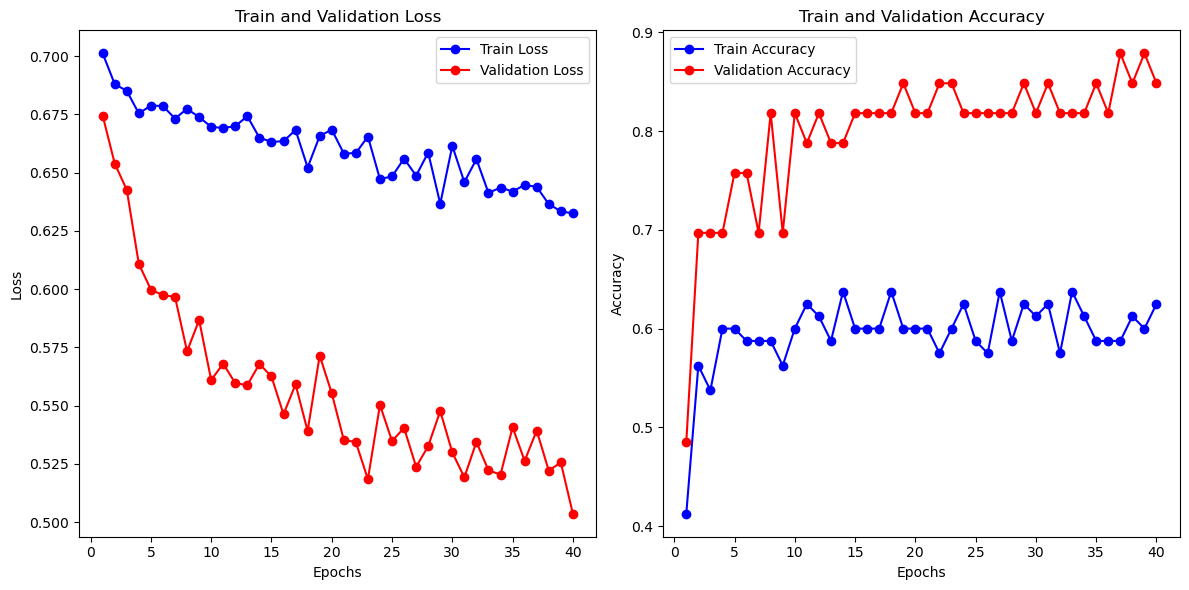

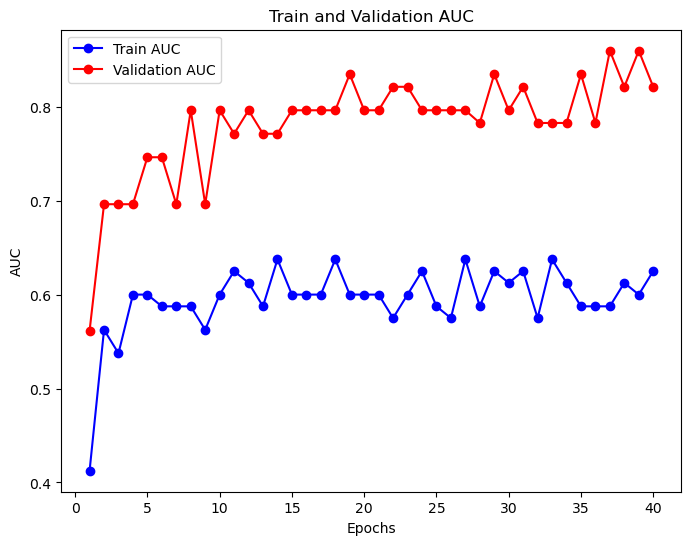

In [8]:
import matplotlib.pyplot as plt

def parse_log_file(log_file_path):
    epochs = []
    train_losses = []
    train_accuracies = []
    train_auc = []
    val_losses = []
    val_accuracies = []
    val_auc = []

    with open(log_file_path, "r") as log_file:
        lines = log_file.readlines()

    for line in lines:
        try:
            if line.startswith("Epoch"):
                epoch = int(line.split('/')[0].split()[1])
                epochs.append(epoch)
            elif line.startswith("Train"):
                train_loss = float(line.split("Loss:")[1].split("|")[0].strip())
                train_accuracy = float(line.split("Acc:")[1].split("|")[0].strip())
                train_auc_score = float(line.split("AUC:")[1].strip())
                train_losses.append(train_loss)
                train_accuracies.append(train_accuracy)
                train_auc.append(train_auc_score)
            elif line.startswith("Val"):
                val_loss = float(line.split("Loss:")[1].split("|")[0].strip())
                val_accuracy = float(line.split("Acc:")[1].split("|")[0].strip())
                val_auc_score = float(line.split("AUC:")[1].strip())
                val_losses.append(val_loss)
                val_accuracies.append(val_accuracy)
                val_auc.append(val_auc_score)
        except IndexError:
            print(f"Skipping line due to format issue: {line}")
            continue

    return epochs, train_losses, train_accuracies, train_auc, val_losses, val_accuracies, val_auc


log_file_path = "training_log.txt"
epochs, train_losses, train_accuracies, train_auc, val_losses, val_accuracies, val_auc = parse_log_file(log_file_path)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss', color='blue', marker='o')
plt.plot(epochs, val_losses, label='Validation Loss', color='red', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Train Accuracy', color='blue', marker='o')
plt.plot(epochs, val_accuracies, label='Validation Accuracy', color='red', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Train and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(epochs, train_auc, label='Train AUC', color='blue', marker='o')
plt.plot(epochs, val_auc, label='Validation AUC', color='red', marker='o')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.title('Train and Validation AUC')
plt.legend()
plt.show()
